# Module 3 — Notebook 2: Balanced Unsupervised Anomaly Models

This notebook trains unsupervised anomaly detection models and evaluates them with a **balanced alert strategy**.

The goal is to keep recall high **without destroying precision**.

The notebook includes:

1. **Balanced F1 threshold**
2. **Precision-floor thresholds**: maximize recall while keeping precision above 0.60, 0.65, or 0.70
3. **Weighted Balanced Ensemble** instead of a noisy OR ensemble
4. Precision, recall, F1, PR-AUC, false alerts, missed anomalies, Top-K metrics, confusion matrices, score distributions, and threshold curves

Models included:

- Rule-Based Baseline
- Isolation Forest
- KNN Local Distance Outlier
- Gaussian Density Model
- PCA Reconstruction
- Robust Z-Score Model
- Autoencoder Reconstruction
- Weighted Balanced Ensemble


In [1]:
import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score, recall_score, f1_score, precision_recall_curve,
    average_precision_score, roc_auc_score, confusion_matrix
)
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.mixture import GaussianMixture

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

SEED = 42
np.random.seed(SEED)

# Balanced alert configuration
# Options: balanced_f1, precision_floor_60, precision_floor_65, precision_floor_70
SELECTED_MODE = 'balanced_f1'

PRECISION_FLOORS = {
    'balanced_f1': 0.60,
    'precision_floor_65': 0.65,
    'precision_floor_70': 0.70,
}

# Folder structure expected:
# Notebooks/Module 3/Unsupervised/02_unsupervised_anomaly_models_balanced.ipynb
# The data preparation output may be in one of the following folders depending on your setup.
possible_input_dirs = [
    Path('../Data Preparation'),
    Path('../Module 3 Data Preparation'),
    Path('../../Module 3 Data Preparation'),
]
INPUT_DIR = next((p for p in possible_input_dirs if (p / 'order_level_anomaly_dataset.csv').exists()), possible_input_dirs[0])
OUTPUT_DIR = Path('../Unsupervised')

MODEL_DIR = OUTPUT_DIR / 'models'
FIGURE_DIR = OUTPUT_DIR / 'figures'
METRIC_DIR = OUTPUT_DIR / 'metrics'
PREDICTION_DIR = OUTPUT_DIR / 'predictions'

for d in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, METRIC_DIR, PREDICTION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATA_PATH = INPUT_DIR / 'order_level_anomaly_dataset.csv'
SCHEMA_PATH = INPUT_DIR / 'anomaly_feature_schema.json'

print('DATA_PATH:', DATA_PATH.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())
print('Selected threshold mode:', SELECTED_MODE)


DATA_PATH: C:\Users\slimc\Desktop\Notebooks\Module 3\Data Preparation\order_level_anomaly_dataset.csv
OUTPUT_DIR: C:\Users\slimc\Desktop\Notebooks\Module 3\Unsupervised
Selected threshold mode: balanced_f1


## 1. Load prepared order-level dataset

In [2]:
df = pd.read_csv(DATA_PATH)
with open(SCHEMA_PATH, 'r', encoding='utf-8') as f:
    schema = json.load(f)

print('Dataset shape:', df.shape)
print('Anomaly rate:', f"{df['is_anomaly'].mean():.3%}")
print('Splits:')
display(df['split'].value_counts().to_frame('n_orders'))
print('Anomaly types:')
display(df['anomaly_type'].value_counts().to_frame('count'))

display(df.head())

Dataset shape: (63049, 77)
Anomaly rate: 1.761%
Splits:


,n_orders
train,44134
test,9458
val,9457


Anomaly types:


,count
normal,61939
suspicious_discount,240
basket_size_outlier,200
void_after_payment,200
price_tampering,180
odd_hour,170
shift_end_void_cluster,120


,order_id,order_date,order_time,order_datetime,cashier_id,customer_id,payment_method,table_number,restaurant_type,main_category,basket_size,n_unique_items,n_unique_categories,total_amount,avg_line_total,max_line_total,min_line_total,avg_item_price,max_item_price,min_item_price,mean_discount_rate,max_discount_rate,discount_line_count,estimated_discount_amount,is_voided_order,void_line_count,void_reason_exists,mean_price_deviation_pct,max_abs_price_deviation_pct,mean_abs_price_deviation_pct,mean_daily_item_quantity,max_daily_item_quantity,mean_demand_zscore,max_abs_demand_zscore,has_discount_order,discount_line_rate,void_line_rate,avg_amount_per_item,unique_item_ratio,cashier_shift,cashier_flagged,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits,customer_visit_gap,customer_visit_ratio,order_hour,order_dayofweek,order_month,is_weekend,is_odd_hour,is_morning,is_lunch,is_dinner,cashier_total_orders,cashier_avg_order_amount,cashier_std_order_amount,cashier_void_rate,cashier_discount_order_rate,cashier_avg_discount_rate,cashier_amount_zscore,customer_total_orders,customer_avg_order_amount,customer_std_order_amount,customer_avg_basket_size,customer_amount_zscore,customer_basket_deviation,anomaly_type,anomaly_description,is_anomaly,split
0,100009,2023-01-01,07:00 AM,2023-01-01 07:00:00,C01,453,cash,21.0,Cafe,Bakery,2,2,2,8.75,4.375,4.50,4.25,4.375,4.50,4.25,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,6.000000,6,3.761034,3.761789,0,0.0,0.0,4.375,1.0,morning,0,regular,mid,morning,weekend,medium,Cafe,"Dessert,Side,Main",26.0,17.0,-9.0,0.653846,7,6,1,1,0,1,0,0,4647,16.969722,9.960514,0.015924,0.116634,0.016107,-0.825231,17,18.735294,11.586789,3.058824,-0.861783,-1.058824,normal,NaN,0,train
1,100000,2023-01-01,07:30 AM,2023-01-01 07:30:00,C02,520,card,12.0,Cafe,Food,3,3,2,16.50,5.500,6.50,4.50,5.500,6.50,4.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,3.666667,5,1.081431,1.283424,0,0.0,0.0,5.500,1.0,morning,0,regular,budget,lunch,any,large,Healthy_Vegan,"Beverage,Side",18.0,14.0,-4.0,0.777778,7,6,1,1,0,1,0,0,4776,16.560787,10.761836,0.014866,0.104481,0.014594,-0.005648,14,26.796429,11.180829,3.928571,-0.920900,-0.928571,normal,NaN,0,train
2,100005,2023-01-01,07:30 AM,2023-01-01 07:30:00,C01,4471,cash,NaN,Cafe,Beverage,2,2,1,9.75,4.875,5.25,4.50,4.875,5.25,4.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,4.000000,4,1.644387,2.071410,0,0.0,0.0,4.875,1.0,morning,0,occasional,budget,morning,weekday,small,Cafe,"Beverage,Main",5.0,5.0,0.0,1.000000,7,6,1,1,0,1,0,0,4647,16.969722,9.960514,0.015924,0.116634,0.016107,-0.724834,5,9.670000,1.922108,2.200000,0.041621,-0.200000,normal,NaN,0,train
3,100012,2023-01-01,07:30 AM,2023-01-01 07:30:00,C02,4488,cash,16.0,Cafe,Beverage,4,4,2,17.50,4.375,6.50,2.50,4.375,6.50,2.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,3.500000,5,0.904188,2.387091,0,0.0,0.0,4.375,1.0,morning,0,occasional,mid,morning,weekend,medium,Cafe,"Side,Food",9.0,8.0,-1.0,0.888889,7,6,1,1,0,1,0,0,4776,16.560787,10.761836,0.014866,0.104481,0.014594,0.087273,8,15.312500,6.441703,3.125000,0.339584,0.875000,normal,NaN,0,train
4,100001,2023-01-01,08:00 AM,2023-01-01 08:00:00,C03,6381,cash,21.0,Cafe,Bakery,2,2,1,8.75,4.375,4.50,4.25,4.375,4.50,4.25,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,4.500000,6,2.231514,3.761789,0,0.0,0.0,4.375,1.0,morning,0,infrequent,mid,morning,any,small,Cafe,"Alcohol,Main,Dessert",4.0,4.0,0.0,1.000000,8,6,1,1,0,1,0,0,4615,16.907545,13.310245,0.015385,0.112026,0.016407,-0.612877,4,15.687500,13.212013,2.250000,-0.525090,-0.250000,normal,NaN,0,train


## 2. Define features and preprocessing

Unsupervised models are fitted on **normal training orders only**. Validation labels are used only to select thresholds and compare models.

In [3]:
numeric_features = [c for c in schema['numeric_features'] if c in df.columns]
binary_features = [c for c in schema['binary_features'] if c in df.columns]
categorical_features = [c for c in schema['categorical_features'] if c in df.columns]

# Remove identifiers and leakage-prone target columns if present
exclude = {
    'order_id', 'customer_id', 'is_anomaly', 'anomaly_type', 'split',
    'order_date', 'order_time', 'order_datetime'
}
numeric_features = [c for c in numeric_features if c not in exclude]
binary_features = [c for c in binary_features if c not in exclude]
categorical_features = [c for c in categorical_features if c not in exclude]

model_features = numeric_features + binary_features + categorical_features

print('Numeric features:', len(numeric_features))
print('Binary features:', len(binary_features))
print('Categorical features:', len(categorical_features))
print('Total model features:', len(model_features))
print('Categorical features:', categorical_features)

Numeric features: 47
Binary features: 9
Categorical features: 9
Total model features: 65
Categorical features: ['payment_method', 'restaurant_type', 'main_category', 'cashier_shift', 'archetype', 'price_tier', 'time_preference', 'day_preference', 'basket_size_bias']


In [4]:
train_df = df[df['split'].eq('train')].copy()
val_df = df[df['split'].eq('val')].copy()
test_df = df[df['split'].eq('test')].copy()

train_normal_df = train_df[train_df['is_anomaly'].eq(0)].copy()

X_train_normal_raw = train_normal_df[model_features]
X_val_raw = val_df[model_features]
X_test_raw = test_df[model_features]

y_val = val_df['is_anomaly'].astype(int).values
y_test = test_df['is_anomaly'].astype(int).values

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features + binary_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train_normal = preprocessor.fit_transform(X_train_normal_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

print('Normal training matrix:', X_train_normal.shape)
print('Validation matrix:', X_val.shape)
print('Test matrix:', X_test.shape)
print('Validation anomalies:', y_val.sum())
print('Test anomalies:', y_test.sum())

Normal training matrix: (43378, 94)
Validation matrix: (9457, 94)
Test matrix: (9458, 94)
Validation anomalies: 178
Test anomalies: 176


## 3. Metric and threshold helpers

In [5]:
def normalize_with_reference(val_scores, test_scores=None):
    """Normalize validation and test scores using validation min/max, so thresholds are comparable."""
    val_scores = np.asarray(val_scores, dtype=float)
    lo, hi = np.nanmin(val_scores), np.nanmax(val_scores)
    if hi - lo < 1e-12:
        val_norm = np.zeros_like(val_scores)
        if test_scores is None:
            return val_norm
        return val_norm, np.zeros_like(np.asarray(test_scores, dtype=float))
    val_norm = (val_scores - lo) / (hi - lo)
    if test_scores is None:
        return val_norm
    test_scores = np.asarray(test_scores, dtype=float)
    test_norm = (test_scores - lo) / (hi - lo)
    test_norm = np.clip(test_norm, 0, 1)
    return val_norm, test_norm


def build_threshold_curve(y_true, scores):
    scores = np.asarray(scores, dtype=float)
    quantiles = np.linspace(0.01, 0.999, 500)
    thresholds = np.unique(np.quantile(scores, quantiles))
    rows = []
    for t in thresholds:
        pred = (scores >= t).astype(int)
        rows.append({
            'threshold': t,
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'f1': f1_score(y_true, pred, zero_division=0),
            'n_alerts': int(pred.sum()),
            'alert_rate': float(pred.mean())
        })
    return pd.DataFrame(rows)


def choose_threshold(curve, mode='balanced_f1', precision_floor=0.60):
    """
    Threshold strategies:
    - balanced_f1: choose threshold with best F1 on validation.
    - precision_floor_xx: maximize recall while keeping precision >= precision_floor.
      If no threshold reaches the precision floor, fall back to best F1.
    """
    if curve.empty:
        return 0.5

    if mode == 'balanced_f1':
        best = curve.sort_values(['f1', 'recall', 'precision'], ascending=[False, False, False]).iloc[0]
        return float(best['threshold'])

    if mode.startswith('precision_floor'):
        candidates = curve[curve['precision'] >= precision_floor].copy()
        if len(candidates) == 0:
            best = curve.sort_values(['f1', 'recall', 'precision'], ascending=[False, False, False]).iloc[0]
            return float(best['threshold'])
        best = candidates.sort_values(['recall', 'f1', 'precision', 'n_alerts'], ascending=[False, False, False, True]).iloc[0]
        return float(best['threshold'])

    raise ValueError(f'Unknown threshold mode: {mode}')


def topk_metrics(y_true, scores, k):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    k = min(k, len(scores))
    idx = np.argsort(scores)[::-1][:k]
    found = int(y_true[idx].sum())
    precision = found / k if k else 0
    recall = found / y_true.sum() if y_true.sum() else 0
    return precision, recall, found


def evaluate_scores(model_name, split, threshold_mode, y_true, scores, threshold):
    scores = np.asarray(scores, dtype=float)
    pred = (scores >= threshold).astype(int)
    precision = precision_score(y_true, pred, zero_division=0)
    recall = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    pr_auc = average_precision_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan
    roc_auc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    p50, r50, f50 = topk_metrics(y_true, scores, 50)
    p100, r100, f100 = topk_metrics(y_true, scores, 100)
    p200, r200, f200 = topk_metrics(y_true, scores, 200)
    return {
        'model': model_name,
        'split': split,
        'threshold_mode': threshold_mode,
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'pr_auc': pr_auc,
        'roc_auc': roc_auc,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'false_alerts': fp,
        'missed_anomalies': fn,
        'alert_count': int(pred.sum()),
        'alert_rate': float(pred.mean()),
        'precision_at_50': p50, 'recall_at_50': r50, 'anomalies_found_at_50': f50,
        'precision_at_100': p100, 'recall_at_100': r100, 'anomalies_found_at_100': f100,
        'precision_at_200': p200, 'recall_at_200': r200, 'anomalies_found_at_200': f200,
    }


def safe_filename(name):
    return name.lower().replace(' ', '_').replace('-', '').replace('/', '_').replace('__', '_')


## 4. Rule-based baseline

This baseline is useful for interpretation even if it is not the final winner.

In [6]:
def rule_based_scores(frame):
    f = frame.copy()
    score = np.zeros(len(f), dtype=float)
    reasons = [[] for _ in range(len(f))]

    def add(condition, weight, reason):
        idx = np.where(condition.fillna(False).values if hasattr(condition, 'fillna') else condition)[0]
        score[idx] += weight
        for i in idx:
            reasons[i].append(reason)

    # Discount signals
    if 'max_discount_rate' in f.columns:
        add(f['max_discount_rate'] >= 0.70, 0.45, 'very_high_discount')
        add((f['max_discount_rate'] >= 0.30) & (f['max_discount_rate'] < 0.70), 0.20, 'high_discount')

    # Void signals
    if 'is_voided_order' in f.columns:
        add(f['is_voided_order'].astype(bool), 0.30, 'voided_order')
    if 'has_void_reason' in f.columns:
        add(f['has_void_reason'].astype(bool), 0.10, 'void_reason_present')

    # Odd hour / shift end
    if 'is_odd_hour' in f.columns:
        add(f['is_odd_hour'].astype(bool), 0.35, 'odd_hour')
    if 'is_shift_end_time' in f.columns:
        add(f['is_shift_end_time'].astype(bool), 0.12, 'shift_end_time')

    # Basket outliers
    if 'basket_size' in f.columns:
        q99 = train_df['basket_size'].quantile(0.99)
        add(f['basket_size'] >= q99, 0.25, 'basket_outlier')

    # Price tampering signals
    for col in ['max_abs_price_deviation_pct', 'max_price_deviation_abs', 'price_deviation_abs_max']:
        if col in f.columns:
            add(f[col] >= 0.30, 0.40, 'large_price_deviation')
            break
    if 'n_price_deviation_lines' in f.columns:
        add(f['n_price_deviation_lines'] > 0, 0.20, 'price_deviation_lines')

    # Cashier behavior
    for col in ['cashier_anomaly_rate', 'cashier_prev_anomaly_rate', 'cashier_risk_score']:
        if col in f.columns:
            q95 = train_df[col].quantile(0.95)
            add(f[col] >= q95, 0.20, 'high_cashier_risk')
            break

    score = np.clip(score, 0, 1)
    reason_text = ['; '.join(r) if r else 'no_rule_triggered' for r in reasons]
    return score, reason_text

rule_val_scores, rule_val_reasons = rule_based_scores(val_df)
rule_test_scores, rule_test_reasons = rule_based_scores(test_df)

## 5. Train and register unsupervised models

In [7]:
results = []
prediction_frames = []
threshold_curves = {}
score_store = {}

threshold_modes = {
    'balanced_f1': {'type': 'balanced_f1', 'precision_floor': None},
    'precision_floor_60': {'type': 'precision_floor', 'precision_floor': 0.60},
    'precision_floor_65': {'type': 'precision_floor', 'precision_floor': 0.65},
    'precision_floor_70': {'type': 'precision_floor', 'precision_floor': 0.70},
}


def register_model(model_name, val_scores_raw, test_scores_raw, test_extra=None):
    val_scores, test_scores = normalize_with_reference(val_scores_raw, test_scores_raw)
    curve = build_threshold_curve(y_val, val_scores)
    threshold_curves[model_name] = curve
    score_store[model_name] = {'val': val_scores, 'test': test_scores, 'thresholds': {}}

    for mode_name, cfg in threshold_modes.items():
        if cfg['type'] == 'balanced_f1':
            threshold = choose_threshold(curve, mode='balanced_f1')
        else:
            threshold = choose_threshold(
                curve,
                mode=mode_name,
                precision_floor=cfg['precision_floor']
            )

        score_store[model_name]['thresholds'][mode_name] = threshold
        results.append(evaluate_scores(model_name, 'val', mode_name, y_val, val_scores, threshold))
        results.append(evaluate_scores(model_name, 'test', mode_name, y_test, test_scores, threshold))

    selected_threshold = score_store[model_name]['thresholds'][SELECTED_MODE]
    tmp = test_df[['order_id', 'split', 'is_anomaly', 'anomaly_type']].copy()
    tmp['model'] = model_name
    tmp['threshold_mode'] = SELECTED_MODE
    tmp['anomaly_score'] = test_scores
    tmp['predicted_is_anomaly'] = (test_scores >= selected_threshold).astype(int)
    if test_extra is not None:
        for k, v in test_extra.items():
            tmp[k] = v
    prediction_frames.append(tmp)

    selected_val = [r for r in results if r['model'] == model_name and r['split'] == 'val' and r['threshold_mode'] == SELECTED_MODE][-1]
    selected_test = [r for r in results if r['model'] == model_name and r['split'] == 'test' and r['threshold_mode'] == SELECTED_MODE][-1]
    print(
        f"{model_name}: threshold={selected_threshold:.4f} | "
        f"val P/R/F1={selected_val['precision']:.3f}/{selected_val['recall']:.3f}/{selected_val['f1']:.3f} | "
        f"test P/R/F1={selected_test['precision']:.3f}/{selected_test['recall']:.3f}/{selected_test['f1']:.3f}"
    )

register_model('Rule-Based Baseline', rule_val_scores, rule_test_scores, test_extra={'rule_reasons': rule_test_reasons})


Rule-Based Baseline: threshold=0.5000 | val P/R/F1=0.884/0.640/0.743 | test P/R/F1=0.908/0.670/0.771


In [8]:
# Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.03,
    max_samples=0.60,
    random_state=SEED,
    n_jobs=-1
)
iso.fit(X_train_normal)
iso_val = -iso.decision_function(X_val)
iso_test = -iso.decision_function(X_test)
register_model('Isolation Forest', iso_val, iso_test)

Isolation Forest: threshold=0.6342 | val P/R/F1=0.431/0.388/0.408 | test P/R/F1=0.343/0.392/0.366


In [9]:
# KNN Local Distance Outlier
# Higher average distance to nearest normal orders means more anomalous.
fit_size = min(12000, X_train_normal.shape[0])
rng = np.random.default_rng(SEED)
fit_idx = rng.choice(X_train_normal.shape[0], size=fit_size, replace=False)
X_knn_fit = X_train_normal[fit_idx]

best_knn = None
for k in [5, 10, 20, 35, 50]:
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean', n_jobs=-1)
    nn.fit(X_knn_fit)
    val_dist, _ = nn.kneighbors(X_val)
    test_dist, _ = nn.kneighbors(X_test)
    val_score = val_dist.mean(axis=1)
    curve = build_threshold_curve(y_val, normalize_with_reference(val_score))
    threshold = choose_threshold(curve, mode=SELECTED_MODE, precision_floor=PRECISION_FLOORS.get(SELECTED_MODE, 0.60))
    val_norm, _ = normalize_with_reference(val_score, test_dist.mean(axis=1))
    val_pred = (val_norm >= threshold).astype(int)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    precision = precision_score(y_val, val_pred, zero_division=0)
    candidate = {'k': k, 'model': nn, 'val_score': val_score, 'test_score': test_dist.mean(axis=1), 'f1': f1, 'recall': recall, 'precision': precision}
    if best_knn is None or (candidate['recall'], candidate['precision'], candidate['f1']) > (best_knn['recall'], best_knn['precision'], best_knn['f1']):
        best_knn = candidate

print('Best KNN k:', best_knn['k'])
register_model('KNN Local Distance Outlier', best_knn['val_score'], best_knn['test_score'])

Best KNN k: 20
KNN Local Distance Outlier: threshold=0.1399 | val P/R/F1=0.675/0.607/0.639 | test P/R/F1=0.656/0.608/0.631


In [10]:
# Gaussian Density Model
# Low likelihood under normal-order distribution means anomalous.
fit_size = min(20000, X_train_normal.shape[0])
rng = np.random.default_rng(SEED)
fit_idx = rng.choice(X_train_normal.shape[0], size=fit_size, replace=False)
X_gmm_fit = X_train_normal[fit_idx]

best_gmm = None
for n_components in [1, 2, 3, 4]:
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='diag',
        reg_covar=1e-6,
        random_state=SEED
    )
    gmm.fit(X_gmm_fit)
    val_score = -gmm.score_samples(X_val)
    test_score = -gmm.score_samples(X_test)
    val_norm, _ = normalize_with_reference(val_score, test_score)
    curve = build_threshold_curve(y_val, val_norm)
    threshold = choose_threshold(curve, mode=SELECTED_MODE, precision_floor=PRECISION_FLOORS.get(SELECTED_MODE, 0.60))
    val_pred = (val_norm >= threshold).astype(int)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    precision = precision_score(y_val, val_pred, zero_division=0)
    candidate = {'n_components': n_components, 'model': gmm, 'val_score': val_score, 'test_score': test_score, 'f1': f1, 'recall': recall, 'precision': precision}
    if best_gmm is None or (candidate['recall'], candidate['precision'], candidate['f1']) > (best_gmm['recall'], best_gmm['precision'], best_gmm['f1']):
        best_gmm = candidate

print('Best GMM components:', best_gmm['n_components'])
register_model('Gaussian Density Model', best_gmm['val_score'], best_gmm['test_score'])

Best GMM components: 3
Gaussian Density Model: threshold=0.0001 | val P/R/F1=0.793/0.798/0.796 | test P/R/F1=0.808/0.835/0.821


In [11]:
# PCA Reconstruction
best_pca = None
for n_components in [0.80, 0.90, 0.95, 0.99]:
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(X_train_normal)
    val_recon = pca.inverse_transform(pca.transform(X_val))
    test_recon = pca.inverse_transform(pca.transform(X_test))
    val_score = ((X_val - val_recon) ** 2).mean(axis=1)
    test_score = ((X_test - test_recon) ** 2).mean(axis=1)
    val_norm, _ = normalize_with_reference(val_score, test_score)
    curve = build_threshold_curve(y_val, val_norm)
    threshold = choose_threshold(curve, mode=SELECTED_MODE, precision_floor=PRECISION_FLOORS.get(SELECTED_MODE, 0.60))
    val_pred = (val_norm >= threshold).astype(int)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    precision = precision_score(y_val, val_pred, zero_division=0)
    candidate = {'n_components': n_components, 'model': pca, 'val_score': val_score, 'test_score': test_score, 'f1': f1, 'recall': recall, 'precision': precision}
    if best_pca is None or (candidate['recall'], candidate['precision'], candidate['f1']) > (best_pca['recall'], best_pca['precision'], best_pca['f1']):
        best_pca = candidate

print('Best PCA components setting:', best_pca['n_components'])
register_model('PCA Reconstruction', best_pca['val_score'], best_pca['test_score'])

Best PCA components setting: 0.95
PCA Reconstruction: threshold=0.0200 | val P/R/F1=0.587/0.590/0.588 | test P/R/F1=0.617/0.585/0.601


In [12]:
# Robust Z-Score Model
# Detects feature-level deviations from the median normal behavior.
median = np.median(X_train_normal, axis=0)
mad = np.median(np.abs(X_train_normal - median), axis=0)
mad = np.where(mad < 1e-6, 1e-6, mad)

val_robust_z = np.abs((X_val - median) / (1.4826 * mad))
test_robust_z = np.abs((X_test - median) / (1.4826 * mad))

# Combine maximum and high percentile deviations to reduce noise.
val_score = 0.7 * np.percentile(val_robust_z, 99, axis=1) + 0.3 * np.max(val_robust_z, axis=1)
test_score = 0.7 * np.percentile(test_robust_z, 99, axis=1) + 0.3 * np.max(test_robust_z, axis=1)

register_model('Robust Z-Score Model', val_score, test_score)

Robust Z-Score Model: threshold=0.3120 | val P/R/F1=0.363/0.483/0.414 | test P/R/F1=0.370/0.500/0.425


In [13]:
# Autoencoder-style reconstruction using MLPRegressor
# Lightweight alternative to a TensorFlow/Keras autoencoder.
fit_size = min(20000, X_train_normal.shape[0])
rng = np.random.default_rng(SEED)
fit_idx = rng.choice(X_train_normal.shape[0], size=fit_size, replace=False)
X_ae_fit = X_train_normal[fit_idx]

input_dim = X_ae_fit.shape[1]
hidden = max(24, min(96, input_dim // 2))
latent = max(8, min(32, input_dim // 6))

ae = MLPRegressor(
    hidden_layer_sizes=(hidden, latent, hidden),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=80,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=8,
    random_state=SEED,
    verbose=False
)
ae.fit(X_ae_fit, X_ae_fit)

val_recon = ae.predict(X_val)
test_recon = ae.predict(X_test)
val_score = ((X_val - val_recon) ** 2).mean(axis=1)
test_score = ((X_test - test_recon) ** 2).mean(axis=1)

register_model('Autoencoder Reconstruction', val_score, test_score)

Autoencoder Reconstruction: threshold=0.0164 | val P/R/F1=0.713/0.640/0.675 | test P/R/F1=0.748/0.642/0.691


## 6. Weighted balanced ensemble

The previous recall-only OR ensemble can destroy precision because one weak model is enough to trigger an alert.

This weighted ensemble combines anomaly scores instead. A transaction must receive a high combined score, not just one isolated trigger.


In [14]:
# # Hybrid unsupervised anomaly detector combining complementary anomaly scores.
ensemble_weights = {
    'Gaussian Density Model': 0.50,
    'PCA Reconstruction': 0.20,
    'KNN Local Distance Outlier': 0.20,
    'Rule-Based Baseline': 0.10,
}
ensemble_weights = {m: w for m, w in ensemble_weights.items() if m in score_store}
weight_sum = sum(ensemble_weights.values())
ensemble_weights = {m: w / weight_sum for m, w in ensemble_weights.items()}

val_ensemble_score = np.zeros(len(y_val), dtype=float)
test_ensemble_score = np.zeros(len(y_test), dtype=float)
for m, w in ensemble_weights.items():
    val_ensemble_score += w * score_store[m]['val']
    test_ensemble_score += w * score_store[m]['test']

register_model('Hybrid Unsupervised Anomaly Detector', val_ensemble_score, test_ensemble_score)

print('Hybrid Unsupervised Anomaly Detector weights:')
display(pd.Series(ensemble_weights).to_frame('weight'))


Hybrid Unsupervised Anomaly Detector: threshold=0.1261 | val P/R/F1=0.759/0.921/0.832 | test P/R/F1=0.806/0.943/0.869
Hybrid Unsupervised Anomaly Detector weights:


,weight
Gaussian Density Model,0.5
PCA Reconstruction,0.2
KNN Local Distance Outlier,0.2
Rule-Based Baseline,0.1


## 7. Model leaderboard

In [15]:
metrics_all = pd.DataFrame(results)
metrics_all.to_csv(METRIC_DIR / 'unsupervised_metrics_all_threshold_modes.csv', index=False)

selected_metrics = metrics_all[
    (metrics_all['threshold_mode'].eq(SELECTED_MODE)) &
    (metrics_all['split'].eq('test'))
].copy()
selected_metrics = selected_metrics.sort_values(['recall', 'precision', 'f1', 'pr_auc'], ascending=[False, False, False, False]).reset_index(drop=True)
selected_metrics.to_csv(METRIC_DIR / 'unsupervised_metrics.csv', index=False)

print('Saved all modes to:', METRIC_DIR / 'unsupervised_metrics_all_threshold_modes.csv')
print('Saved selected-mode test metrics to:', METRIC_DIR / 'unsupervised_metrics.csv')
print('Selected mode:', SELECTED_MODE)

display(selected_metrics[[
    'model', 'precision', 'recall', 'f1', 'pr_auc', 'roc_auc',
    'false_alerts', 'missed_anomalies', 'alert_count', 'alert_rate',
    'precision_at_50', 'recall_at_50', 'precision_at_100', 'recall_at_100',
    'precision_at_200', 'recall_at_200'
]])

all_predictions = pd.concat(prediction_frames, ignore_index=True)
all_predictions.to_csv(PREDICTION_DIR / 'unsupervised_predictions.csv', index=False)
print('Saved predictions to:', PREDICTION_DIR / 'unsupervised_predictions.csv')


Saved all modes to: ..\Unsupervised\metrics\unsupervised_metrics_all_threshold_modes.csv
Saved selected-mode test metrics to: ..\Unsupervised\metrics\unsupervised_metrics.csv
Selected mode: balanced_f1


,model,precision,recall,f1,pr_auc,roc_auc,false_alerts,missed_anomalies,alert_count,alert_rate,precision_at_50,recall_at_50,precision_at_100,recall_at_100,precision_at_200,recall_at_200
0,Hybrid Unsupervised Anomaly Detector,0.805825,0.943182,0.869110,0.952129,0.998923,40,10,206,0.021781,1.00,0.284091,1.00,0.568182,0.820,0.931818
1,Gaussian Density Model,0.807692,0.835227,0.821229,0.908014,0.997946,35,29,182,0.019243,1.00,0.284091,0.94,0.534091,0.770,0.875000
2,Rule-Based Baseline,0.907692,0.670455,0.771242,0.737539,0.992436,12,58,130,0.013745,0.76,0.215909,0.88,0.500000,0.675,0.767045
3,Autoencoder Reconstruction,0.748344,0.642045,0.691131,0.693372,0.939226,38,63,151,0.015965,0.98,0.278409,0.88,0.500000,0.605,0.687500
4,KNN Local Distance Outlier,0.656442,0.607955,0.631268,0.630008,0.909608,56,69,163,0.017234,1.00,0.284091,0.83,0.471591,0.545,0.619318
5,PCA Reconstruction,0.616766,0.585227,0.600583,0.564576,0.885814,64,73,167,0.017657,0.86,0.244318,0.67,0.380682,0.560,0.636364
6,Robust Z-Score Model,0.369748,0.500000,0.425121,0.372017,0.719309,150,88,238,0.025164,0.82,0.232955,0.55,0.312500,0.390,0.443182
7,Isolation Forest,0.343284,0.392045,0.366048,0.315877,0.846336,132,107,201,0.021252,0.58,0.164773,0.46,0.261364,0.345,0.392045


Saved predictions to: ..\Unsupervised\predictions\unsupervised_predictions.csv


## 8. Compare balanced vs recall-focused thresholds

In [16]:
comparison = metrics_all[metrics_all['split'].eq('test')].copy()
comparison = comparison.sort_values(['model', 'threshold_mode'])
comparison.to_csv(METRIC_DIR / 'threshold_mode_comparison.csv', index=False)

display(comparison[[
    'model', 'threshold_mode', 'precision', 'recall', 'f1',
    'false_alerts', 'missed_anomalies', 'alert_count', 'alert_rate'
]])

,model,threshold_mode,precision,recall,f1,false_alerts,missed_anomalies,alert_count,alert_rate
49,Autoencoder Reconstruction,balanced_f1,0.748344,0.642045,0.691131,38,63,151,0.015965
51,Autoencoder Reconstruction,precision_floor_60,0.580952,0.693182,0.632124,88,54,210,0.022203
53,Autoencoder Reconstruction,precision_floor_65,0.748344,0.642045,0.691131,38,63,151,0.015965
55,Autoencoder Reconstruction,precision_floor_70,0.748344,0.642045,0.691131,38,63,151,0.015965
25,Gaussian Density Model,balanced_f1,0.807692,0.835227,0.821229,35,29,182,0.019243
27,Gaussian Density Model,precision_floor_60,0.602837,0.965909,0.742358,112,6,282,0.029816
29,Gaussian Density Model,precision_floor_65,0.689362,0.920455,0.788321,73,14,235,0.024847
31,Gaussian Density Model,precision_floor_70,0.725581,0.886364,0.797954,59,20,215,0.022732
57,Hybrid Unsupervised Anomaly Detector,balanced_f1,0.805825,0.943182,0.869110,40,10,206,0.021781
59,Hybrid Unsupervised Anomaly Detector,precision_floor_60,0.621429,0.988636,0.763158,106,2,280,0.029605


## 9. Global comparison plots

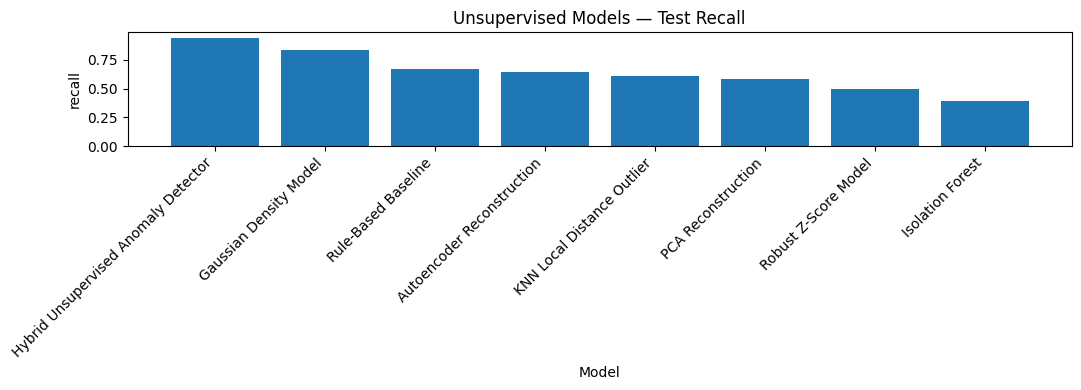

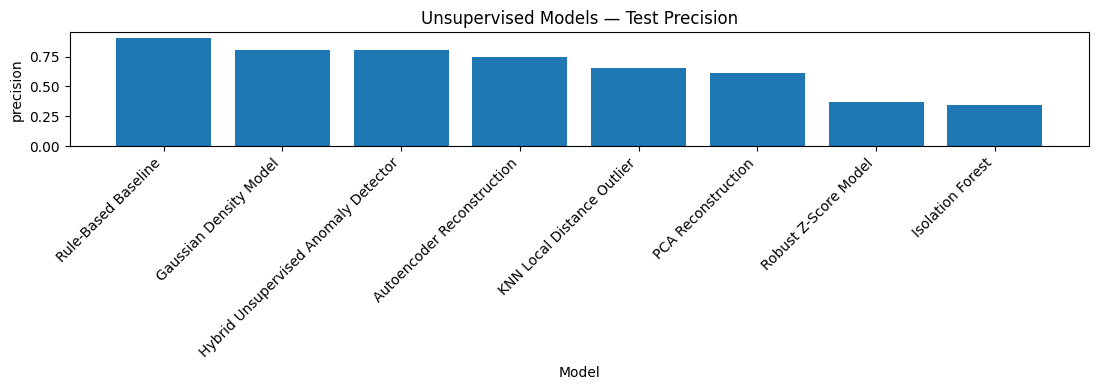

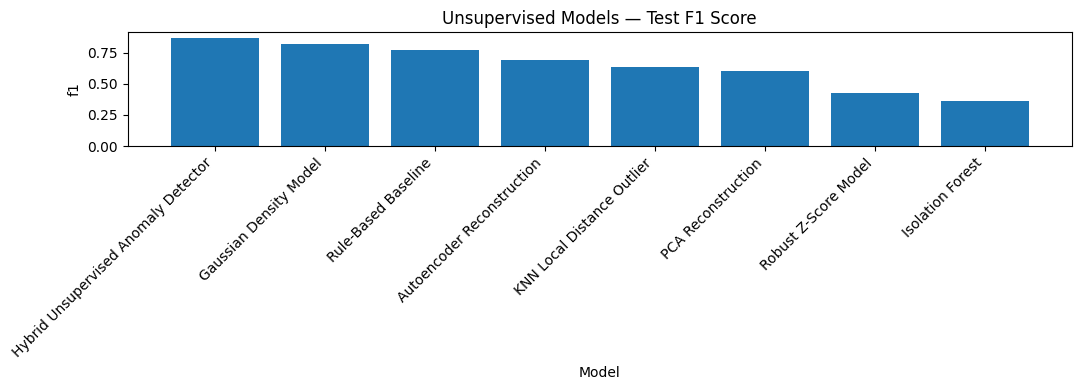

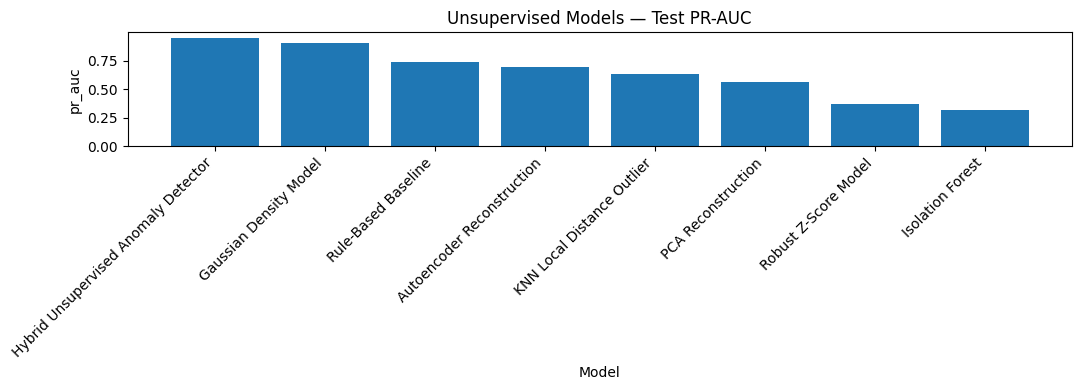

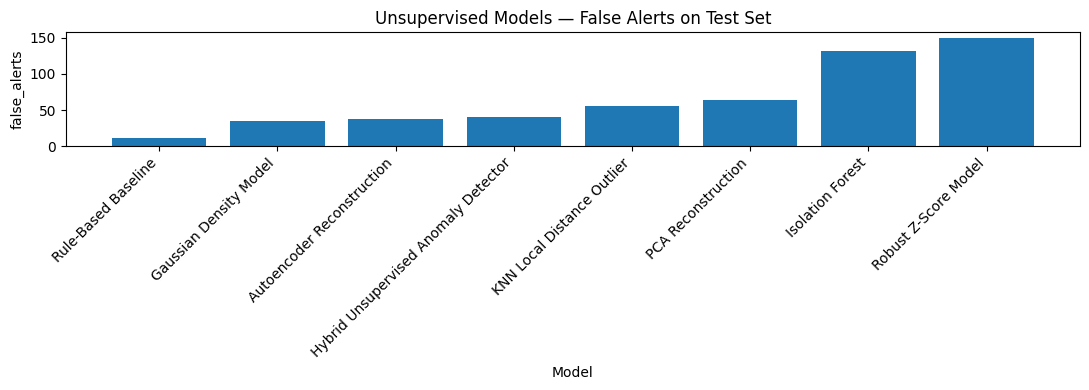

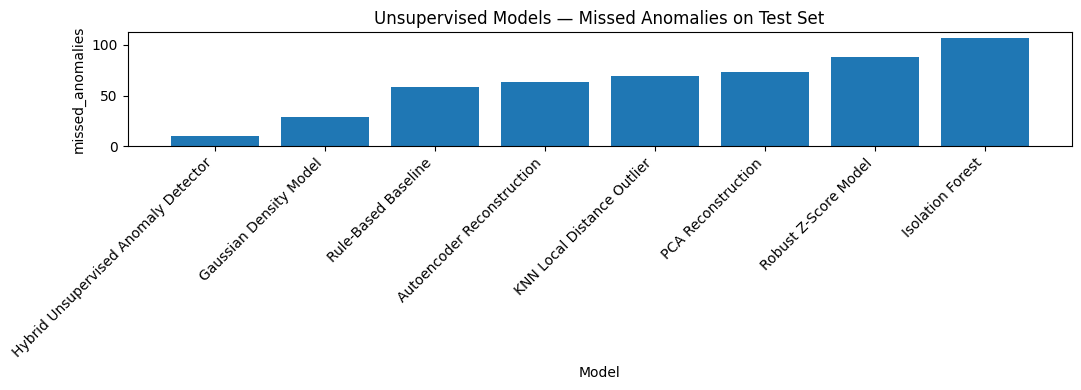

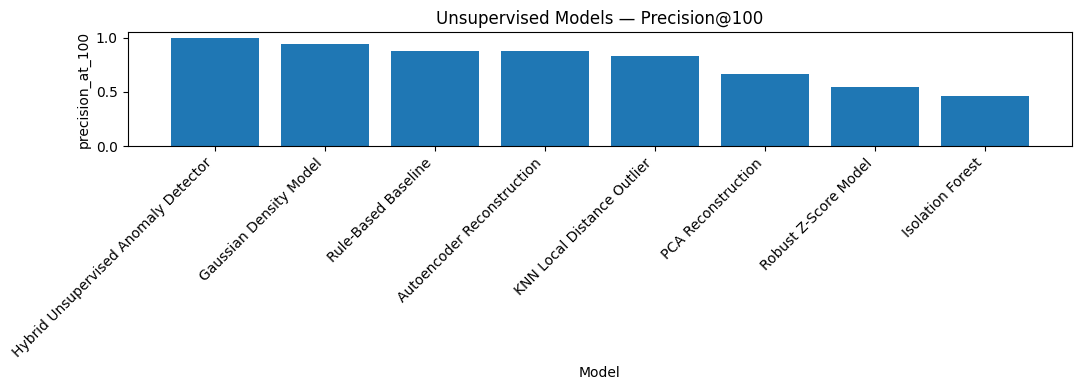

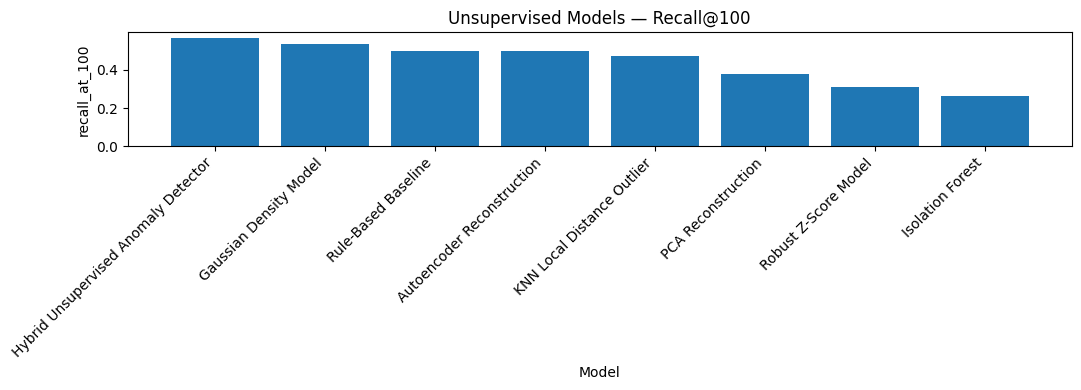

In [17]:
test_metrics = selected_metrics.copy()


def safe_filename(name):
    return name.lower().replace(' ', '_').replace('-', '').replace('__', '_')


def bar_plot(metric, title, filename, sort_by=None, ascending=False):
    data = test_metrics.copy()
    if sort_by is None:
        sort_by = metric
    data = data.sort_values(sort_by, ascending=ascending)
    plt.figure(figsize=(11, 4))
    plt.bar(data['model'], data[metric])
    plt.title(title)
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=150)
    plt.show()

bar_plot('recall', 'Unsupervised Models — Test Recall', 'unsupervised_test_recall.png')
bar_plot('precision', 'Unsupervised Models — Test Precision', 'unsupervised_test_precision.png')
bar_plot('f1', 'Unsupervised Models — Test F1 Score', 'unsupervised_test_f1_scores.png')
bar_plot('pr_auc', 'Unsupervised Models — Test PR-AUC', 'unsupervised_test_pr_auc.png')
bar_plot('false_alerts', 'Unsupervised Models — False Alerts on Test Set', 'unsupervised_false_alerts.png', ascending=True)
bar_plot('missed_anomalies', 'Unsupervised Models — Missed Anomalies on Test Set', 'unsupervised_missed_anomalies.png', ascending=True)
bar_plot('precision_at_100', 'Unsupervised Models — Precision@100', 'unsupervised_precision_at_100.png')
bar_plot('recall_at_100', 'Unsupervised Models — Recall@100', 'unsupervised_recall_at_100.png')

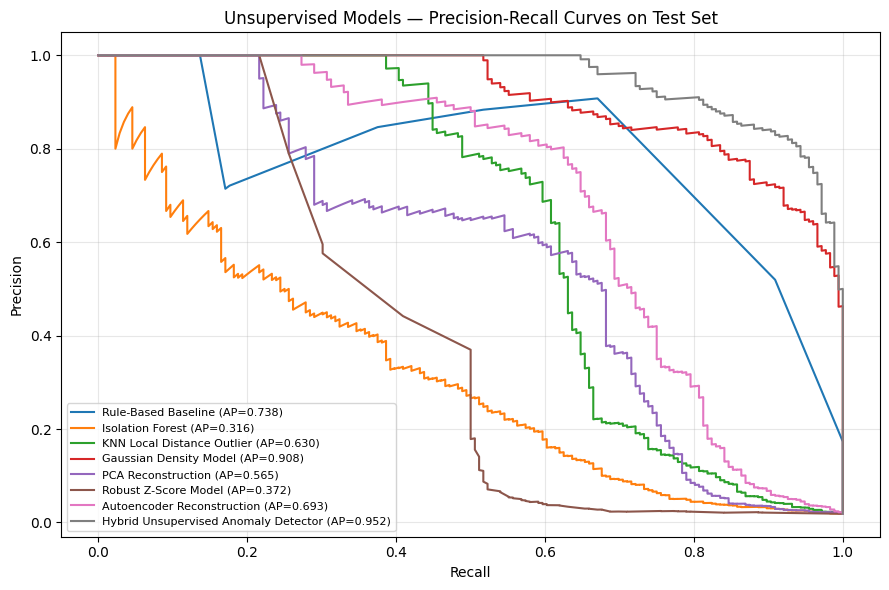

In [18]:
# Precision-Recall curves
plt.figure(figsize=(9, 6))
for model_name, store in score_store.items():
    scores = store['test']
    p, r, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    plt.plot(r, p, label=f'{model_name} (AP={ap:.3f})')
plt.title('Unsupervised Models — Precision-Recall Curves on Test Set')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'unsupervised_precision_recall_curves.png', dpi=150)
plt.show()

## 10. Per-model diagnostic plots


MODEL: Rule-Based Baseline


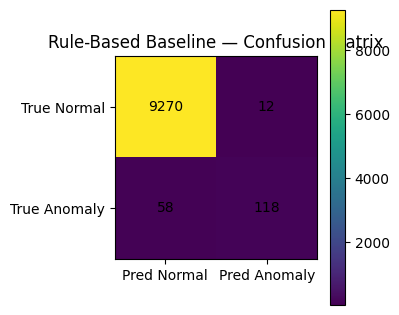

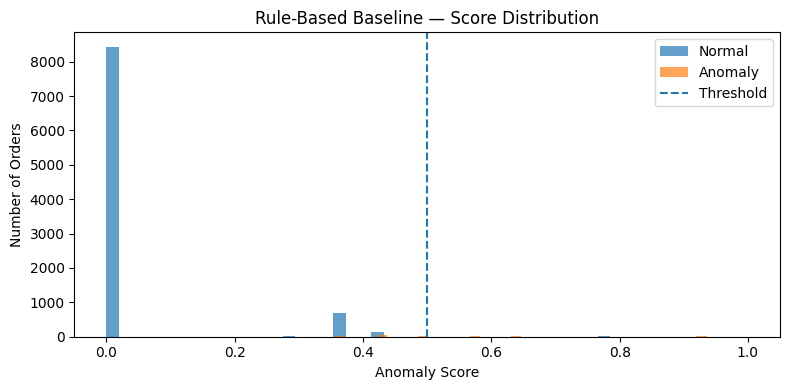

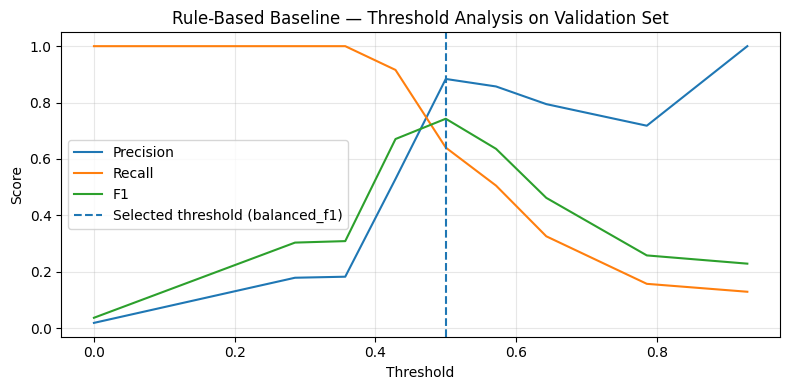


MODEL: Isolation Forest


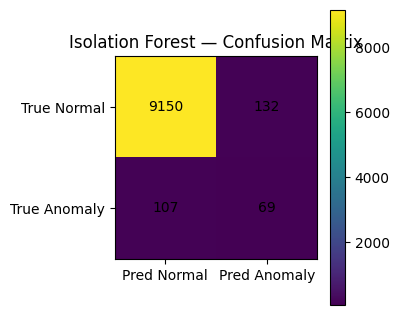

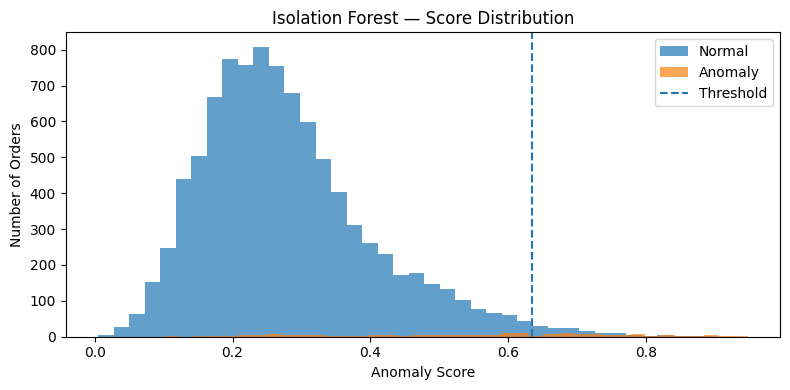

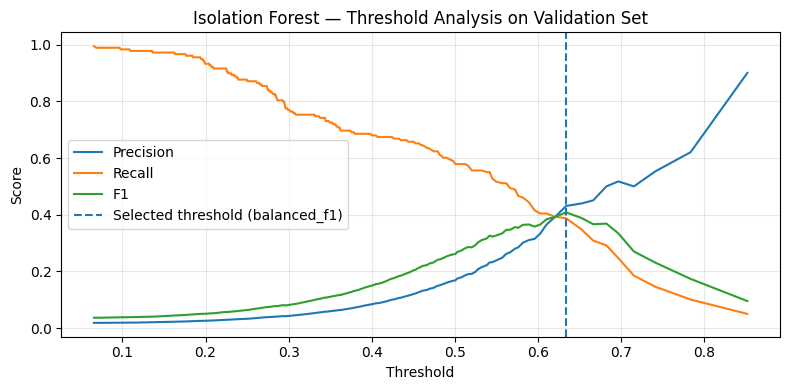


MODEL: KNN Local Distance Outlier


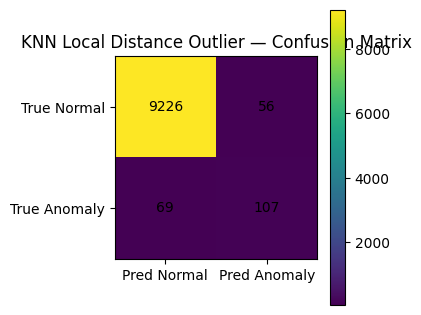

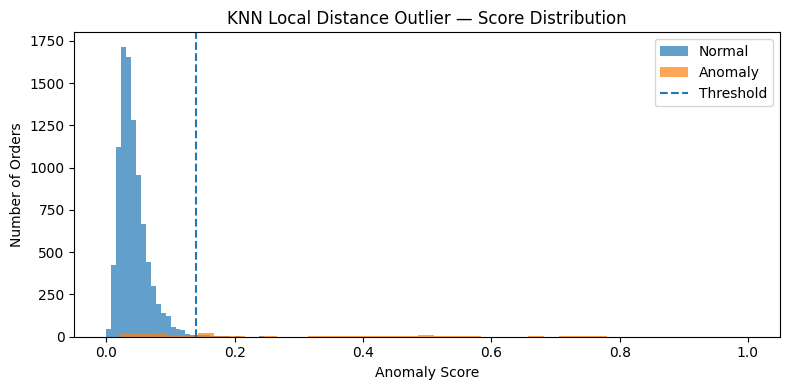

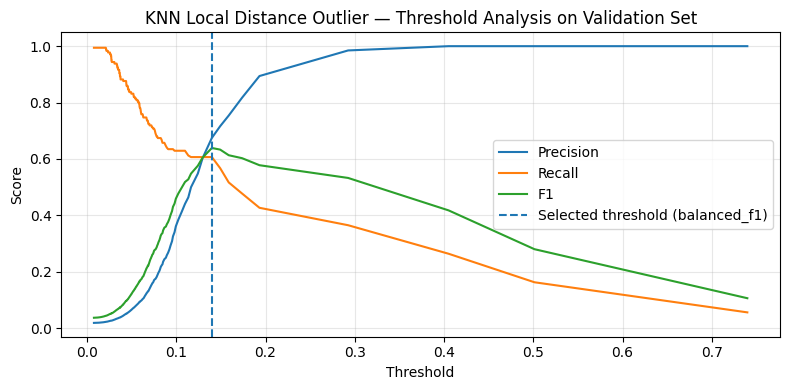


MODEL: Gaussian Density Model


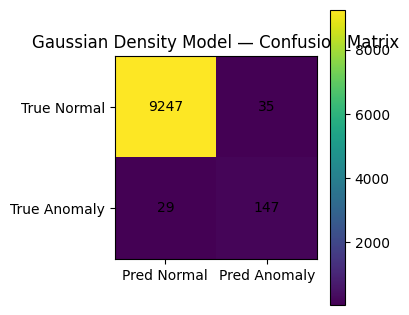

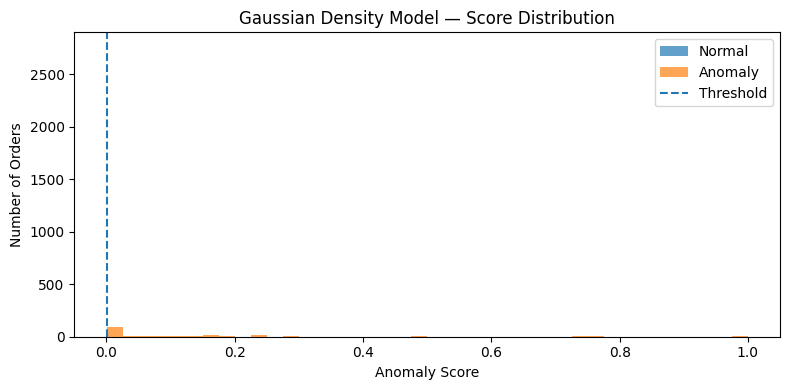

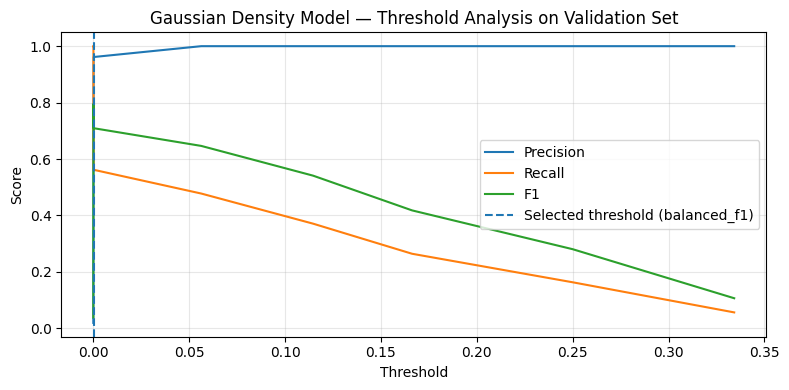


MODEL: PCA Reconstruction


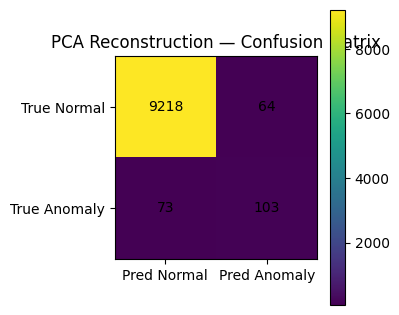

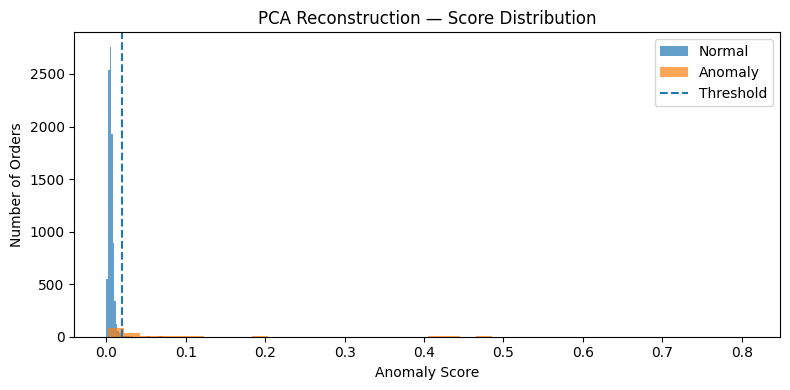

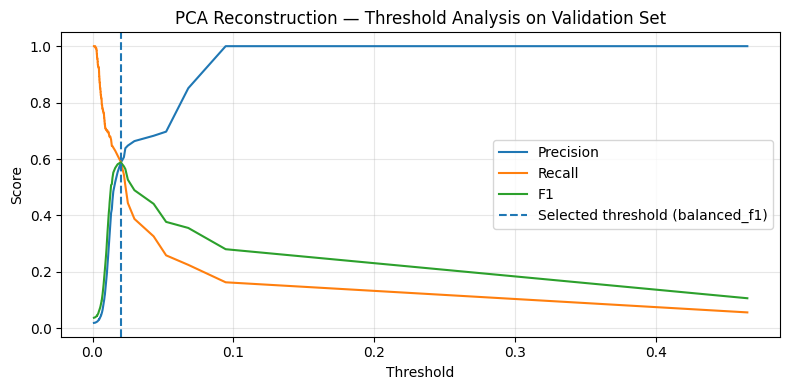


MODEL: Robust Z-Score Model


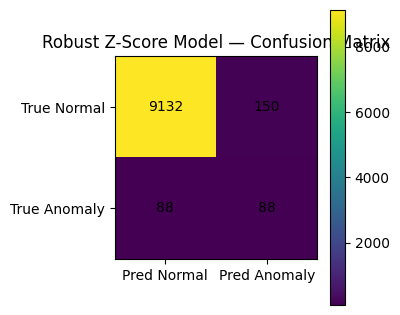

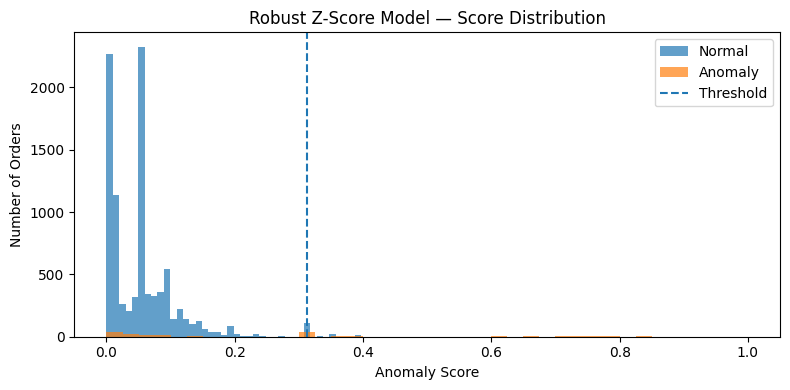

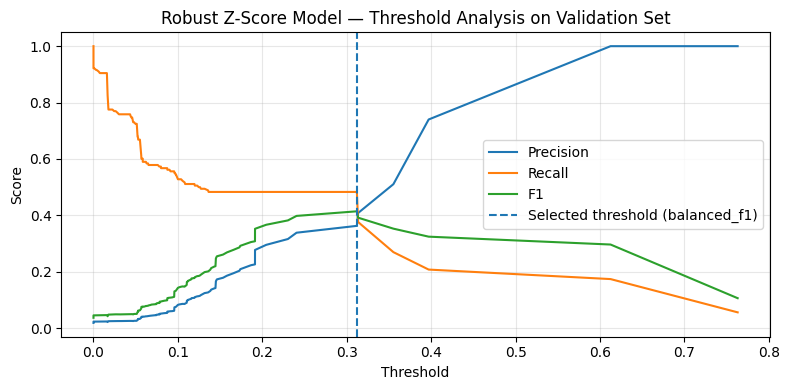


MODEL: Autoencoder Reconstruction


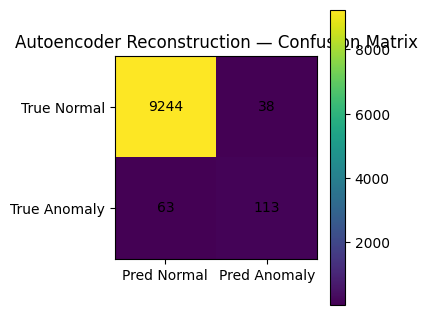

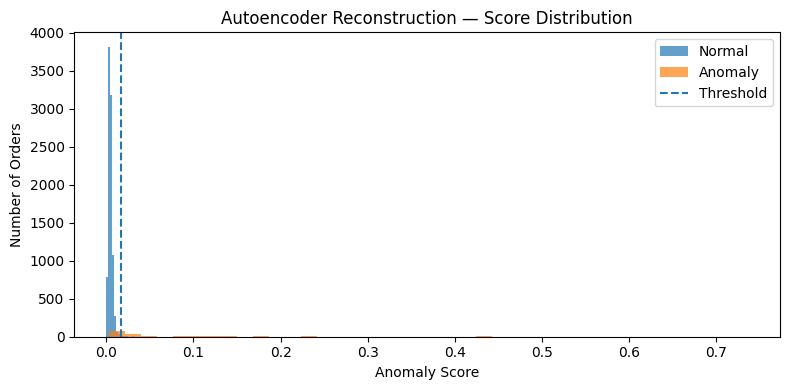

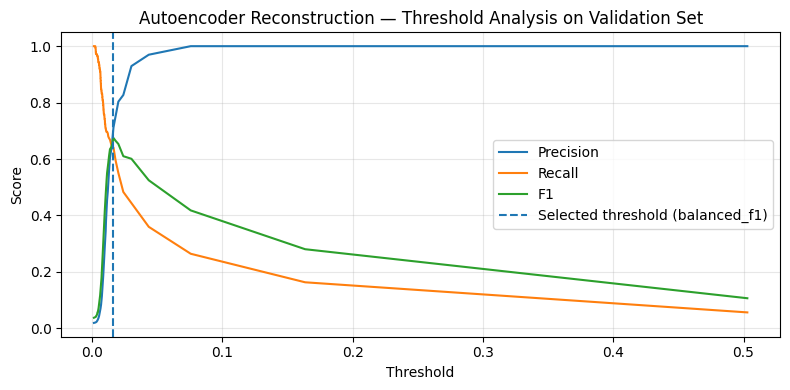


MODEL: Hybrid Unsupervised Anomaly Detector


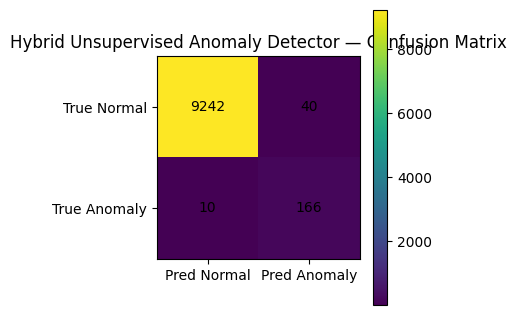

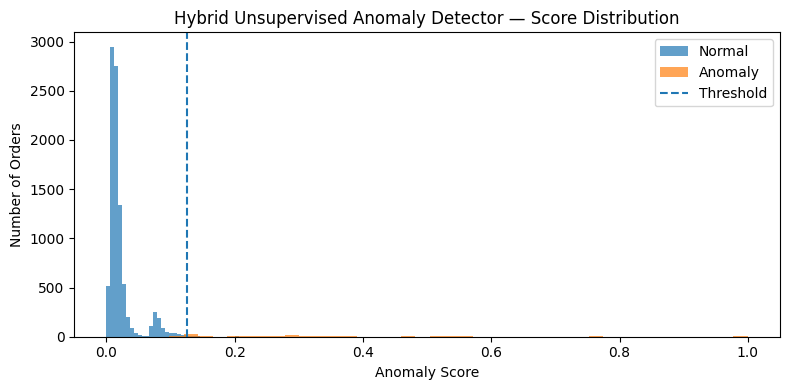

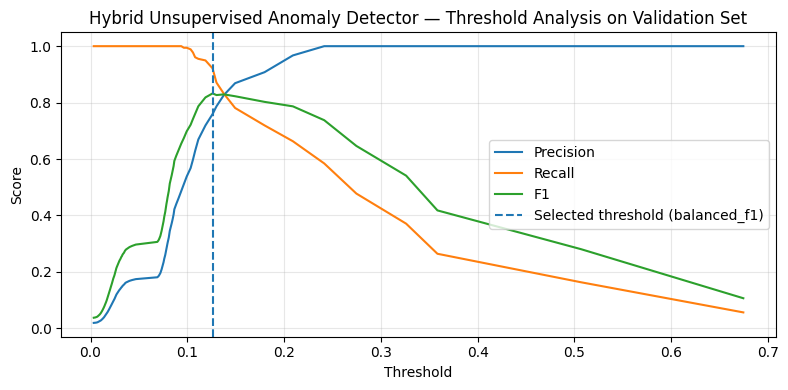

In [19]:
def get_pred_and_threshold(model_name):
    store = score_store[model_name]
    if 'pred_test' in store:
        return store['pred_test'], np.nan
    threshold = store['thresholds'][SELECTED_MODE]
    pred = (store['test'] >= threshold).astype(int)
    return pred, threshold


def plot_confusion_matrix(model_name, y_true, scores):
    pred, threshold = get_pred_and_threshold(model_name)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    plt.figure(figsize=(4, 3.5))
    plt.imshow(cm)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xticks([0, 1], ['Pred Normal', 'Pred Anomaly'])
    plt.yticks([0, 1], ['True Normal', 'True Anomaly'])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'{safe_filename(model_name)}_confusion_matrix.png', dpi=150)
    plt.show()


def plot_score_distribution(model_name, y_true, scores):
    pred, threshold = get_pred_and_threshold(model_name)
    plt.figure(figsize=(8, 4))
    plt.hist(scores[y_true == 0], bins=40, alpha=0.7, label='Normal')
    plt.hist(scores[y_true == 1], bins=40, alpha=0.7, label='Anomaly')
    if not np.isnan(threshold):
        plt.axvline(threshold, linestyle='--', label='Threshold')
    plt.title(f'{model_name} — Score Distribution')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Number of Orders')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'{safe_filename(model_name)}_score_distribution.png', dpi=150)
    plt.show()


def plot_threshold_curve(model_name):
    if model_name not in threshold_curves:
        return
    curve = threshold_curves[model_name]
    plt.figure(figsize=(8, 4))
    plt.plot(curve['threshold'], curve['precision'], label='Precision')
    plt.plot(curve['threshold'], curve['recall'], label='Recall')
    plt.plot(curve['threshold'], curve['f1'], label='F1')
    if SELECTED_MODE in score_store[model_name]['thresholds']:
        t = score_store[model_name]['thresholds'][SELECTED_MODE]
        plt.axvline(t, linestyle='--', label=f'Selected threshold ({SELECTED_MODE})')
    plt.title(f'{model_name} — Threshold Analysis on Validation Set')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'{safe_filename(model_name)}_threshold_analysis.png', dpi=150)
    plt.show()

for model_name, store in score_store.items():
    print('\nMODEL:', model_name)
    plot_confusion_matrix(model_name, y_test, store['test'])
    plot_score_distribution(model_name, y_test, store['test'])
    plot_threshold_curve(model_name)


## 11. Per-anomaly-type recall

In [20]:
rows = []
for model_name, store in score_store.items():
    pred, _ = get_pred_and_threshold(model_name)
    tmp = test_df[['anomaly_type', 'is_anomaly']].copy()
    tmp['pred'] = pred
    for anomaly_type, group in tmp[tmp['is_anomaly'].eq(1)].groupby('anomaly_type'):
        rows.append({
            'model': model_name,
            'anomaly_type': anomaly_type,
            'n_true': len(group),
            'n_detected': int(group['pred'].sum()),
            'recall': group['pred'].mean(),
        })
per_type_recall = pd.DataFrame(rows)
per_type_recall.to_csv(METRIC_DIR / 'per_anomaly_type_recall_unsupervised.csv', index=False)

display(per_type_recall.pivot(index='anomaly_type', columns='model', values='recall').fillna(0))

model,Autoencoder Reconstruction,Gaussian Density Model,Hybrid Unsupervised Anomaly Detector,Isolation Forest,KNN Local Distance Outlier,PCA Reconstruction,Robust Z-Score Model,Rule-Based Baseline
anomaly_type,,,,,,,,
basket_size_outlier,1.000000,1.000000,1.000000,0.366667,1.000000,1.000000,0.00000,0.466667
odd_hour,0.968750,1.000000,1.000000,0.031250,0.031250,0.875000,0.03125,1.000000
price_tampering,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,1.000000
shift_end_void_cluster,0.266667,0.400000,0.933333,0.600000,0.933333,0.266667,1.00000,0.066667
suspicious_discount,1.000000,1.000000,1.000000,0.684211,1.000000,0.710526,1.00000,1.000000
void_after_payment,0.294118,0.411765,0.735294,0.647059,0.705882,0.411765,1.00000,0.176471


## 12. Highest-risk alerts per model

In [21]:
for model_name in score_store:
    print('\nTop alerts for:', model_name)
    top = all_predictions[all_predictions['model'].eq(model_name)].sort_values('anomaly_score', ascending=False).head(10)
    cols = ['order_id', 'is_anomaly', 'anomaly_type', 'anomaly_score', 'predicted_is_anomaly']
    if 'rule_reasons' in top.columns:
        cols.append('rule_reasons')
    display(top[cols])



Top alerts for: Rule-Based Baseline


,order_id,is_anomaly,anomaly_type,anomaly_score,predicted_is_anomaly,rule_reasons
8243,161742,1,odd_hour,1.000000,1,voided_order; odd_hour; basket_outlier
6701,160204,1,suspicious_discount,1.000000,1,very_high_discount; basket_outlier
737,154242,1,suspicious_discount,1.000000,1,very_high_discount; basket_outlier
4014,157522,1,suspicious_discount,1.000000,1,very_high_discount; basket_outlier
5844,159341,1,basket_size_outlier,0.928571,1,basket_outlier; large_price_deviation
8222,161690,1,basket_size_outlier,0.928571,1,basket_outlier; large_price_deviation
9248,162744,1,price_tampering,0.928571,1,basket_outlier; large_price_deviation
8039,161522,1,basket_size_outlier,0.928571,1,basket_outlier; large_price_deviation
1621,155138,1,basket_size_outlier,0.928571,1,basket_outlier; large_price_deviation
9225,162684,1,basket_size_outlier,0.928571,1,basket_outlier; large_price_deviation



Top alerts for: Isolation Forest


,order_id,is_anomaly,anomaly_type,anomaly_score,predicted_is_anomaly,rule_reasons
17757,161801,1,void_after_payment,0.947420,1,NaN
9968,154025,1,suspicious_discount,0.934290,1,NaN
17701,161742,1,odd_hour,0.932088,1,NaN
10810,154876,1,suspicious_discount,0.920523,1,NaN
15509,159567,0,normal,0.906380,1,NaN
14406,158459,1,suspicious_discount,0.895529,1,NaN
17490,161539,1,suspicious_discount,0.890996,1,NaN
18081,162125,1,shift_end_void_cluster,0.887311,1,NaN
16604,162984,1,basket_size_outlier,0.886573,1,NaN
18021,162115,0,normal,0.880381,1,NaN



Top alerts for: KNN Local Distance Outlier


...

,order_id,is_anomaly,anomaly_type,anomaly_score,predicted_is_anomaly,rule_reasons
47633,153848,1,suspicious_discount,1.000000,1,NaN
52213,158448,1,suspicious_discount,0.969715,1,NaN
56275,162482,1,suspicious_discount,0.851963,1,NaN
52069,158296,1,suspicious_discount,0.846471,1,NaN
50753,156988,1,suspicious_discount,0.846471,1,NaN
54622,160818,1,suspicious_discount,0.846471,1,NaN
48941,155144,1,suspicious_discount,0.846471,1,NaN
54289,160495,1,suspicious_discount,0.846471,1,NaN
54150,160361,1,suspicious_discount,0.846471,1,NaN
53225,159441,1,suspicious_discount,0.846471,1,NaN



Top alerts for: Autoencoder Reconstruction


,order_id,is_anomaly,anomaly_type,anomaly_score,predicted_is_anomaly,rule_reasons
59708,162955,1,basket_size_outlier,0.736083,1,NaN
61091,162990,1,basket_size_outlier,0.622013,1,NaN
61238,162994,1,basket_size_outlier,0.604423,1,NaN
57389,162982,1,basket_size_outlier,0.567795,1,NaN
61763,163015,1,basket_size_outlier,0.546798,1,NaN
65298,163021,1,basket_size_outlier,0.536064,1,NaN
65597,162999,1,basket_size_outlier,0.530934,1,NaN
63894,162984,1,basket_size_outlier,0.523320,1,NaN
64673,162985,1,basket_size_outlier,0.508170,1,NaN
64705,162974,1,basket_size_outlier,0.507327,1,NaN



Top alerts for: Hybrid Unsupervised Anomaly Detector


,order_id,is_anomaly,anomaly_type,anomaly_score,predicted_is_anomaly,rule_reasons
68485,155866,1,odd_hour,1.000000,1,NaN
74428,161690,1,basket_size_outlier,1.000000,1,NaN
71544,158853,1,basket_size_outlier,1.000000,1,NaN
68775,156139,1,odd_hour,0.988172,1,NaN
66772,154065,1,odd_hour,0.964242,1,NaN
73352,162984,1,basket_size_outlier,0.949225,1,NaN
71541,158896,1,odd_hour,0.772896,1,NaN
69701,157041,1,odd_hour,0.772554,1,NaN
67466,154846,1,odd_hour,0.771344,1,NaN
67051,154436,1,odd_hour,0.771338,1,NaN


## Notebook conclusion

This notebook compares unsupervised anomaly detection models using a balanced thresholding strategy.

Instead of forcing recall at any cost, the selected threshold mode maximizes recall while enforcing a minimum precision floor. This is more realistic for a POS alert system because missed anomalies are costly, but too many false alerts can reduce manager trust.

The final unsupervised candidate should be selected based on:

- Recall and missed anomalies
- Precision and false alerts
- PR-AUC and Top-K alert quality
- Per-anomaly-type recall
- Practical usefulness in a dashboard
